In [12]:
import pandas as pd
df = pd.read_csv(r'c:\Users\Lekshmi Priya\Downloads\Lab_Exam_binary_classification_dataset.csv')
df.head()

,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes
3,1.4250,500,No
4,1.7750,628,No


In [13]:
df.describe()

,Feature1,Feature2
count,1020.000000,1020.000000
mean,11.436679,520.988235
std,313.061049,69.793442
min,1.250000,400.000000
25%,1.450000,464.000000
50%,1.637500,520.000000
75%,1.828125,584.000000
max,10000.000000,640.000000


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  999 non-null    float64
 1   Feature2  999 non-null    int64  
 2   Target    999 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 31.2 KB


In [14]:
pd.isnull(df).sum()

Feature1     0
Feature2     0
Target      20
dtype: int64

In [15]:
df['Target'] = df['Target'].map({'Yes': 1, 'No': 0})
df.head()

,Feature1,Feature2,Target
0,1.7250,520,1.0
1,1.8875,428,0.0
2,1.6000,552,1.0
3,1.4250,500,0.0
4,1.7750,628,0.0


Text(0.5, 1.0, 'Feature1 vs Feature2')

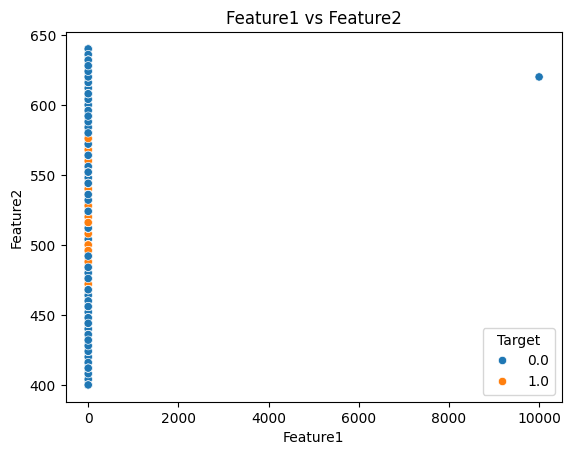

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x='Feature1', y='Feature2', hue='Target', data=df)
plt.title('Feature1 vs Feature2')   

In [22]:
df = df[df['Feature1'] < 1000]

Text(0.5, 1.0, 'Feature1 vs Feature2')

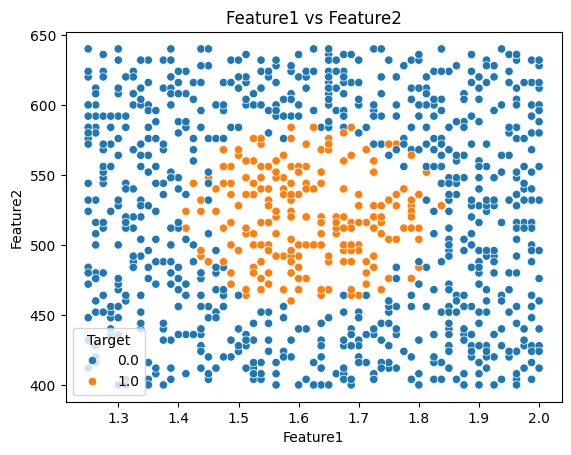

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x='Feature1', y='Feature2', hue='Target', data=df)
plt.title('Feature1 vs Feature2') 

In [27]:
df = df.dropna(subset=['Target'])

In [28]:
X = df[['Feature1', 'Feature2']]
y = df['Target']

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

c:\Users\Lekshmi Priya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


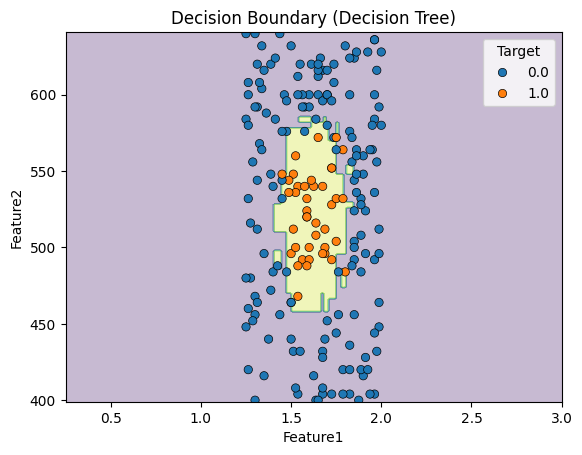

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a mesh grid
x_min, x_max = X['Feature1'].min() - 1, X['Feature1'].max() + 1
y_min, y_max = X['Feature2'].min() - 1, X['Feature2'].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Flatten grid and scale it
grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)

# Predict for each point in grid
Z = model.predict(grid_scaled)
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot actual test points
sns.scatterplot(x=X_test['Feature1'], y=X_test['Feature2'], hue=y_test, edgecolor='k')

plt.title('Decision Boundary (Decision Tree)')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.show()

In [35]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.955


In [37]:
from sklearn.metrics import f1_score

print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.9010989010989011


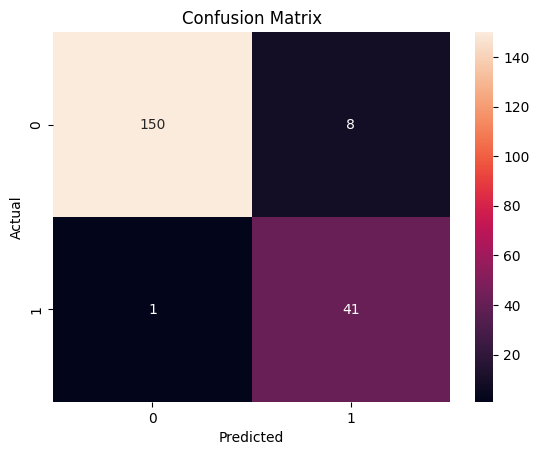

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()